### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import canny
from scipy import ndimage as ndi

# Datacheck imports.
from numpy import ndarray
from numpy import uint8
from numpy import float64


### Helper Functions

In [2]:
def get_axes(nrows: int, ncols: int, fig_size: tuple[int, int]) -> ndarray:
    """
    A helper function to create a "canvas" (Figure) with multiple "plots" (Axes).
    This keeps the main code clean.
    """
    _, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=fig_size)
    # .ravel() converts a 2D grid of axes into a 1D list so we can use ax[0], ax[1], etc.
    return axes.ravel()

## Edge Based Segmentation

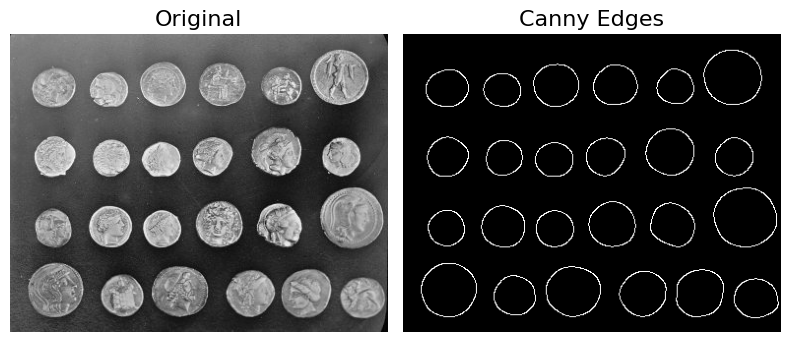

In [3]:
# Standard deviation of the Gaussian filter.
# Controls the level of smoothening to reduce noise.
# A gigher sigma detects edges em bigger scales.
SIGMA: int = 5

FONT_SIZE: int = 16

# Load the 'coins' image in grayscale. In grayscale, a pixel is just a number from 0 (black) to 255 (white).
image: ndarray[uint8] = data.coins()

# Edge filter an image using the Canny algorithm.
# Returns the binary edge map. (Edge detection).
edges: ndarray[uint8] = canny(image=image, sigma=SIGMA)

ax: ndarray[uint8] = get_axes(nrows=1, ncols=2, fig_size=(8,5))

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title("Original", fontsize=FONT_SIZE)
ax[0].set_axis_off()

ax[1].imshow(edges, cmap=plt.cm.gray)
ax[1].set_title("Canny Edges", fontsize=FONT_SIZE)
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

### Filled Holes in Edge Segmentation

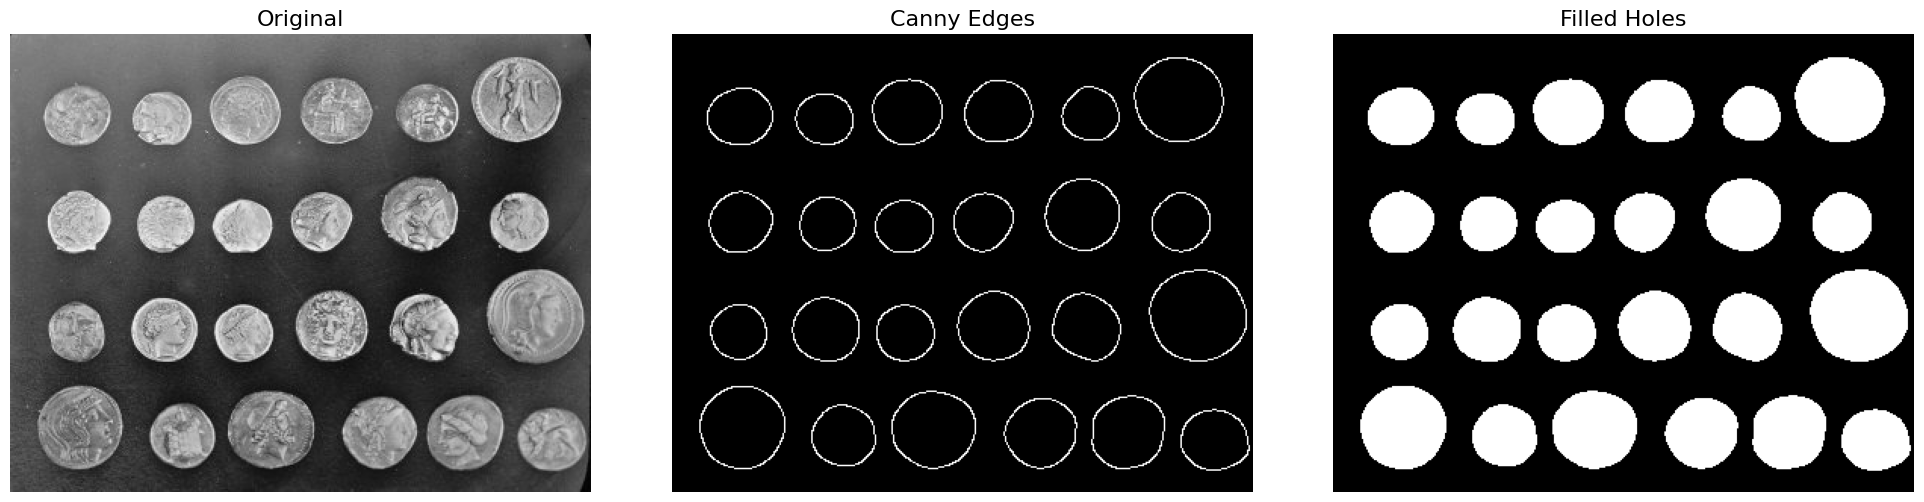

In [4]:
# Fill the holes in binary objects.
filled_edges_holes: ndarray[float64] = ndi.binary_fill_holes(input=edges)

ax = get_axes(nrows=1, ncols=3, fig_size=(20,5))
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title("Original", fontsize=FONT_SIZE)
ax[0].set_axis_off()

ax[1].imshow(edges, cmap=plt.cm.gray)
ax[1].set_title("Canny Edges", fontsize=FONT_SIZE)
ax[1].set_axis_off()

ax[2].imshow(filled_edges_holes, cmap=plt.cm.gray)
ax[2].set_title("Filled Holes", fontsize=FONT_SIZE)
ax[2].set_axis_off()

plt.tight_layout()
plt.show()

### Variating Sigma

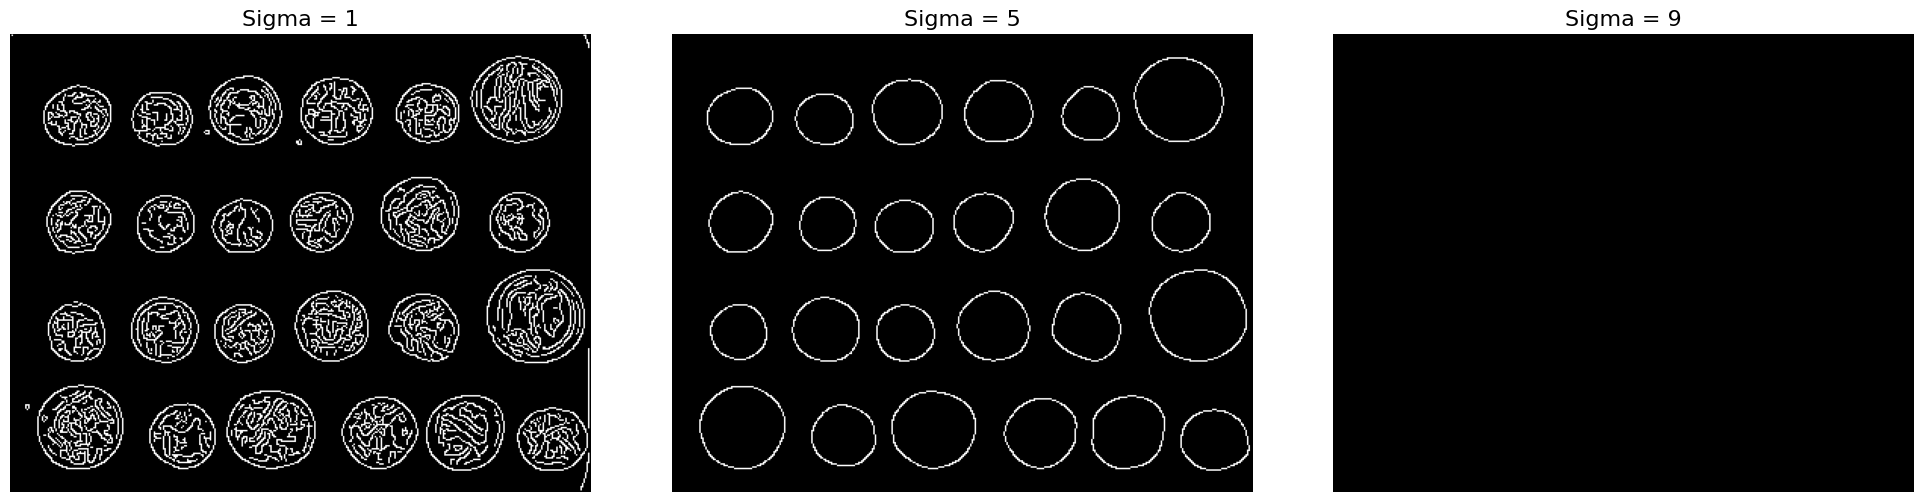

In [5]:
# Different sigmas to see the difference.
ax = get_axes(nrows=1, ncols=3, fig_size=(20,5))

i: int = 1
for a in ax:
    a.set_axis_off()
    edges = canny(image=image, sigma=i)
    a.imshow(edges, cmap=plt.cm.gray)
    a.set_title(f"Sigma = {i}", fontsize=FONT_SIZE)
    i += 4

plt.tight_layout()
plt.show()